# UA Semantic Search 


## Stage 1: Problem Definition & Data Acquisition

### What problem are we solving?

We build **semantic search** over **University of Alabama (UA) student resources**: given a natural-language question, return the most relevant official services and pages.

### Why it matters; limits of keyword search

Campus websites are organized by **department names** and **menus**, not by how students phrase tasks. **Keyword** search misses **synonyms** and **paraphrases** (e.g. “check my grades” vs “grade report”). That motivates **lexical baselines (TF–IDF)** and **dense embeddings (SentenceTransformers)**.

### Dataset documentation

| Item | Description |
|------|-------------|
| **Source** | Self-collected public UA listings; enriched via `fill_dataset.py`. Primary file: **`ua_resources_filled.xlsx`** (fallback: `ua_resources.xlsx`). |
| **Samples** | Row and column counts print in the next cell after load. |
| **Unit** | One row per **resource** (service or information page). |

**Key columns:** `resource_name`, `category`, `subcategory`, `url`, `description`, `target_users`, `keywords`, `student_queries`.

### Ethical considerations

Only **public** information; **no** private student records. Some fields may be **AI-assisted** and can be wrong—results are **assistive**, not authoritative.


### Stage 1 EDA

Loaded: ua_resources_filled.xlsx  |  shape: (334, 13)


,id,resource_name,category,subcategory,description,target_users,keywords,url,access_type,last_verified,step,student_queries,search_text
0,1.0,Academic Calendar,Quick Links,NaN,Used to provide important dates and deadlines ...,"students, faculty, staff","academic calendar, university dates, semester ...",https://registrar.ua.edu/academiccalendar/,NaN,NaT,NaN,- What are the important dates for the upcomin...,academic calendar academic calendar academic c...
1,2.0,Blackboard,Quick Links,NaN,"Used to access and manage course materials, as...","students, faculty, staff","Blackboard login, access course materials, vie...",https://ualearn.blackboard.com/webapps/bb-auth...,NaN,NaT,NaN,How do I log into Blackboard? Where can I find...,blackboard blackboard blackboard how do i log ...
2,3.0,Degree Works,Quick Links,NaN,"Allows students to track degree progress, requ...",Undergraduate Students,"degree audit, graduation progress, course plan...",https://degreeworks.ua.edu,UA Login Required,2026-03-01,NaN,NaN,degree works degree works degree works allow...


id                        float64
resource_name              object
category                   object
subcategory                object
description                object
target_users               object
keywords                   object
url                        object
access_type                object
last_verified      datetime64[ns]
step                      float64
student_queries            object
search_text                object
dtype: object
Rows before → after dedup: 334 → 312


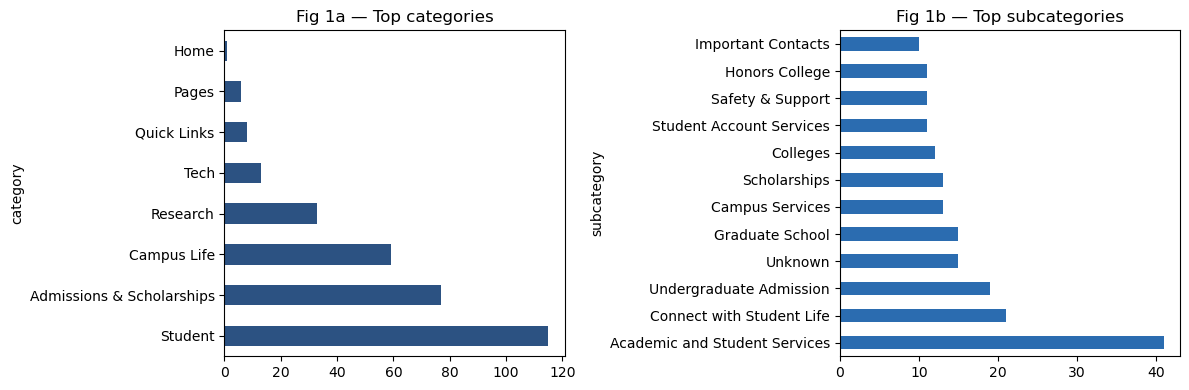

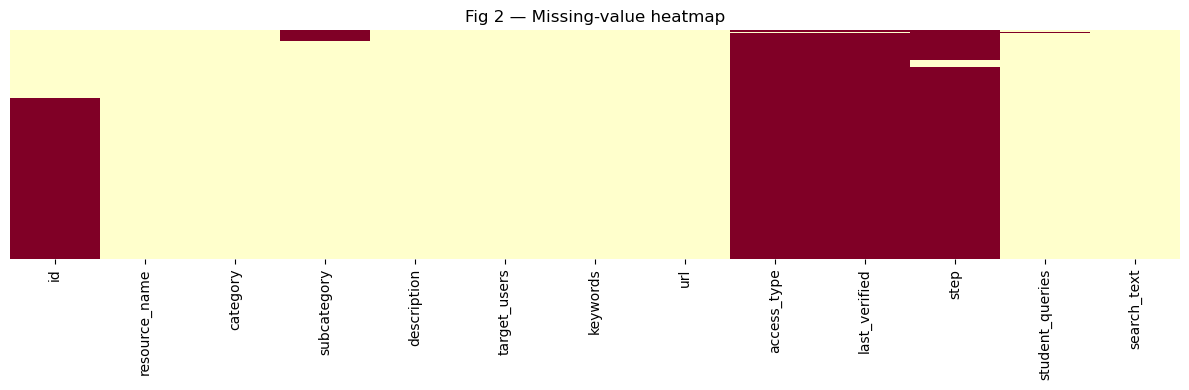

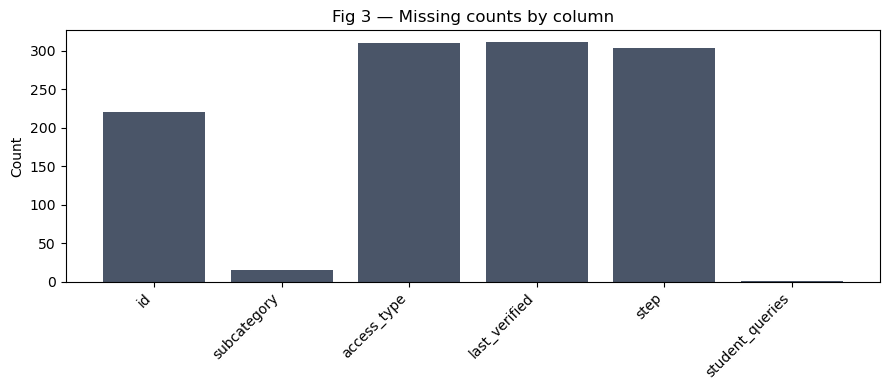

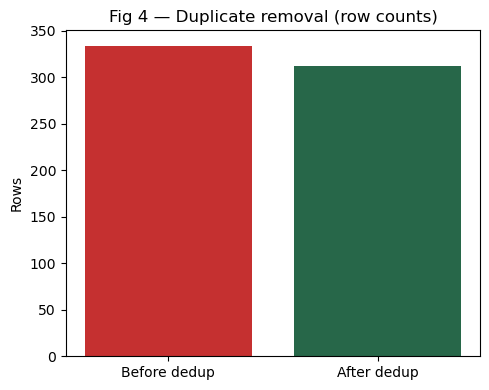

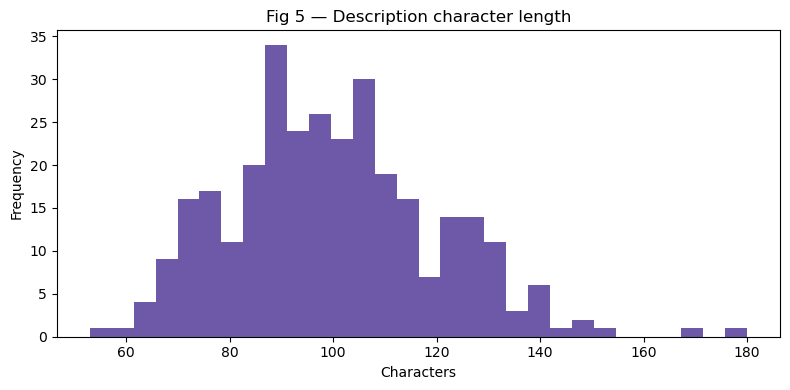

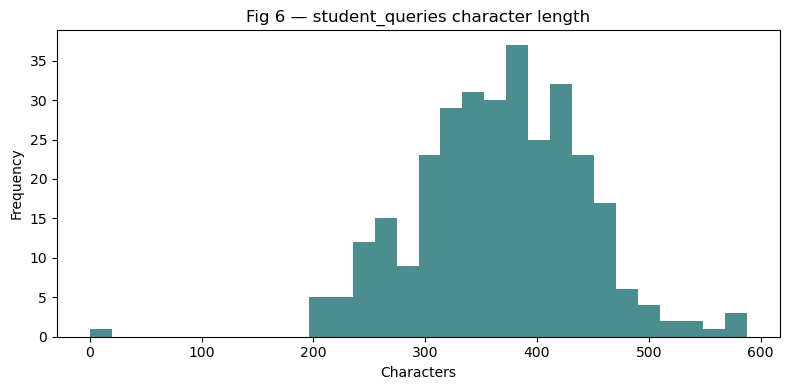

In [2]:
# --- Stage 1: load, deduplicate, visualize ---
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

DATA_FILE = "ua_resources_filled.xlsx"
if not Path(DATA_FILE).exists():
    DATA_FILE = "ua_resources.xlsx"

df = pd.read_excel(DATA_FILE)
print(f"Loaded: {DATA_FILE}  |  shape: {df.shape}")
display(df.head(3))
print(df.dtypes)

df["resource_name"] = df["resource_name"].astype(str).str.strip()
rows_before = len(df)
df = df.drop_duplicates(subset=["resource_name"], keep="first").reset_index(drop=True)
rows_after = len(df)
print(f"Rows before → after dedup: {rows_before} → {rows_after}")

# Fig 1a–b: category distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["category"].fillna("").value_counts().head(12).plot(kind="barh", ax=axes[0], color="#2c5282")
axes[0].set_title("Fig 1a — Top categories")
df["subcategory"].fillna("Unknown").value_counts().head(12).plot(kind="barh", ax=axes[1], color="#2b6cb0")
axes[1].set_title("Fig 1b — Top subcategories")
plt.tight_layout()
plt.show()

# Fig 2: missing heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="YlOrRd")
plt.title("Fig 2 — Missing-value heatmap")
plt.tight_layout()
plt.show()

# Fig 3: missing counts
miss = df.isnull().sum()
miss = miss[miss > 0]
plt.figure(figsize=(9, 4))
plt.bar(miss.index.astype(str), miss.values, color="#4a5568")
plt.title("Fig 3 — Missing counts by column")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Fig 4: dedup row counts
plt.figure(figsize=(5, 4))
plt.bar(["Before dedup", "After dedup"], [rows_before, rows_after], color=["#c53030", "#276749"])
plt.title("Fig 4 — Duplicate removal (row counts)")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

# Fig 5–6: text length distributions
dl = df["description"].fillna("").str.len()
plt.figure(figsize=(8, 4))
plt.hist(dl, bins=30, color="#553c9a", alpha=0.85)
plt.title("Fig 5 — Description character length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

sq = df["student_queries"].fillna("").astype(str).str.len()
plt.figure(figsize=(8, 4))
plt.hist(sq, bins=30, color="#2c7a7b", alpha=0.85)
plt.title("Fig 6 — student_queries character length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Interpretation — each figure

- **Fig 1a–b:** Where the catalog concentrates across **categories** and **subcategories** (balance vs long tail).
- **Fig 2:** **Missingness** across columns (pattern of sparsity).
- **Fig 3:** **Numeric** missing counts (easy to cite).
- **Fig 4:** Effect of **deduplication** on catalog size.
- **Fig 5:** **Description** length — lexical signal available per row.
- **Fig 6:** **Student-query** field length — coverage of example queries.

## Stage 2: Data Cleaning & Feature Engineering

We impute missing text fields, normalize strings, build **`search_text`**, and add **≥3 engineered features** with justification below.


In [3]:
# --- Stage 2: missing values (before / after) ---
_nulls_before = df.isnull().sum()
print("BEFORE imputation:")
print(_nulls_before)

df["subcategory"] = df["subcategory"].fillna("Unknown")
for col in ["description", "keywords", "student_queries", "category"]:
    df[col] = df[col].fillna("")
df["target_users"] = df["target_users"].fillna("")

_nulls_after = df.isnull().sum()
print("\nAFTER imputation:")
print(_nulls_after)

compare = pd.DataFrame({"missing_before": _nulls_before, "missing_after": _nulls_after})
compare["delta"] = compare["missing_after"] - compare["missing_before"]
display(compare)
print("Row count:", len(df))


BEFORE imputation:
id                 220
resource_name        0
category             0
subcategory         15
description          0
target_users         0
keywords             0
url                  0
access_type        310
last_verified      311
step               303
student_queries      1
search_text          0
dtype: int64

AFTER imputation:
id                 220
resource_name        0
category             0
subcategory          0
description          0
target_users         0
keywords             0
url                  0
access_type        310
last_verified      311
step               303
student_queries      0
search_text          0
dtype: int64


,missing_before,missing_after,delta
id,220,220,0
resource_name,0,0,0
category,0,0,0
subcategory,15,0,-15
description,0,0,0
target_users,0,0,0
keywords,0,0,0
url,0,0,0
access_type,310,310,0
last_verified,311,311,0


Row count: 312


### Text normalization

Strip whitespace on names; titles for display consistency (optional for retrieval string, which is lowercased later).


In [4]:
df["resource_name"] = df["resource_name"].str.strip()
df["subcategory"] = df["subcategory"].astype(str).str.strip()
df["resource_name"] = df["resource_name"].str.title()


### Feature engineering (≥3 features + `search_text`)

| Feature | Why |
|---------|-----|
| **`search_text`** | Single retrieval string; name & student queries weighted higher. |
| **`text_length`** | How much text the model sees per row. |
| **`keyword_count`** | Richness of the keyword field. |
| **`has_description`** | Flag for non-empty description (data quality). |
| **`category_code`** | Integer encoding of category for numeric summaries / correlation. |


,resource_name,text_length,keyword_count,has_description,category_code
0,Academic Calendar,932,11,1,4
1,Blackboard,645,12,1,4
2,Degree Works,199,6,1,4
3,Email,869,11,1,4
4,Events Calendar,712,10,1,4


,text_length,keyword_count,has_description,category_code
text_length,1.000,0.292,NaN,-0.162
keyword_count,0.292,1.000,NaN,-0.096
has_description,NaN,NaN,NaN,NaN
category_code,-0.162,-0.096,NaN,1.000


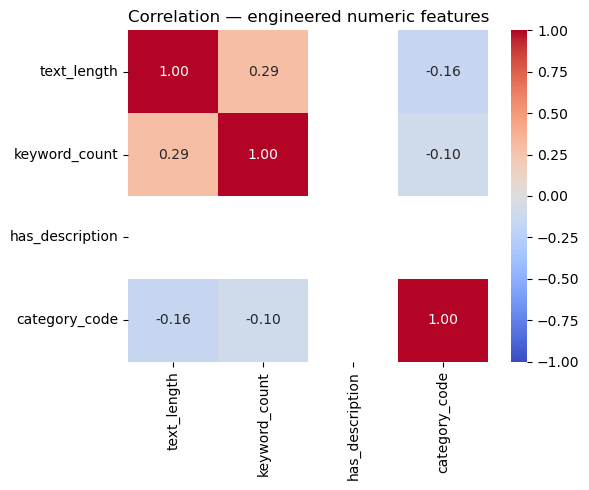

In [5]:
# --- search_text + engineered features ---
df["search_text"] = (
    (df["resource_name"] + " ") * 3
    + (df["student_queries"] + " ") * 2
    + df["description"] + " "
    + df["keywords"] + " "
    + df["category"] + " "
    + df["subcategory"]
).str.lower()

df["text_length"] = df["search_text"].str.len()
df["keyword_count"] = df["keywords"].apply(
    lambda s: len([t for t in re.split(r"[\s,]+", str(s).strip()) if t])
)
df["has_description"] = (df["description"].fillna("").str.len() > 0).astype(int)
df["category_code"] = df["category"].fillna("").astype("category").cat.codes

display(df[["resource_name", "text_length", "keyword_count", "has_description", "category_code"]].head(5))

num = df[["text_length", "keyword_count", "has_description", "category_code"]].corr()
display(num.round(3))
plt.figure(figsize=(6, 5))
sns.heatmap(num, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation — engineered numeric features")
plt.tight_layout()
plt.show()


### Feature selection

**Models (Stage 3)** consume **`search_text` only** for fair TF-IDF vs embedding comparison. Numeric features support **EDA** and this correlation view—not as extra inputs to those two vectorizers.


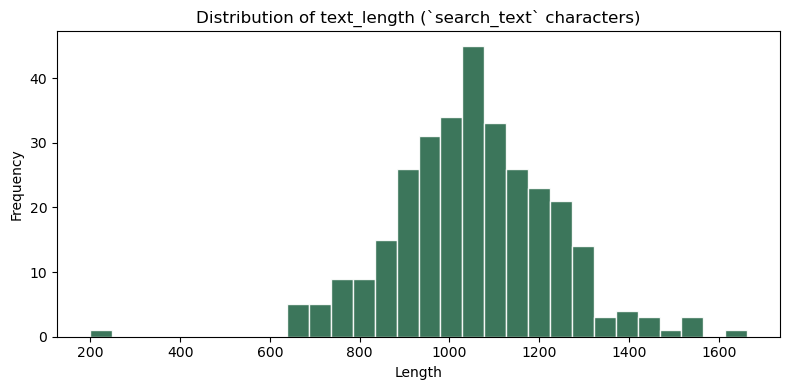

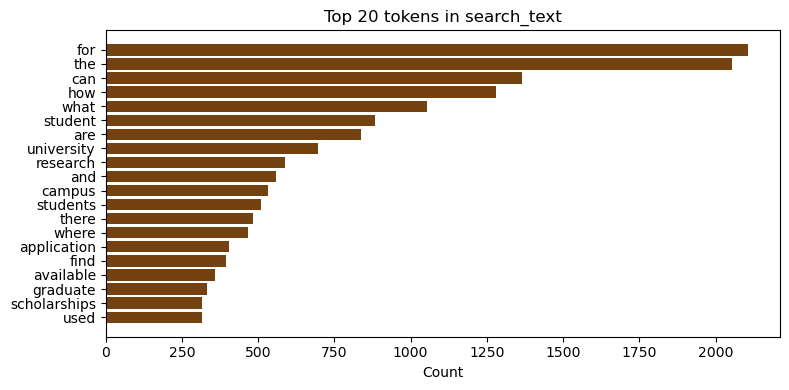

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(df["text_length"], bins=30, color="#276749", edgecolor="white", alpha=0.9)
plt.title("Distribution of text_length (`search_text` characters)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

tokens = []
for t in df["search_text"].dropna().astype(str):
    tokens += re.findall(r"[a-zA-Z]{3,}", t.lower())
top = Counter(tokens).most_common(20)
plt.figure(figsize=(8, 4))
plt.barh([w for w, _ in reversed(top)], [c for _, c in reversed(top)], color="#744210")
plt.title("Top 20 tokens in search_text")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


## Stage 3: Modeling & Evaluation

### Two model families (required)

1. **TF-IDF + cosine similarity** — sparse baseline; **`ParameterGrid`** over `max_features`, `ngram_range`, `min_df`.
2. **SentenceTransformer (`all-MiniLM-L6-v2`) + cosine** — dense semantic similarity.

### Splits & metrics

- **Resources:** random **80% / 10% / 10%** train / val / test (reported in code).
- **Queries:** fixed labeled list; **TF-IDF** hyperparameters chosen by **MRR on a 4-query train subset**; **Precision@5, Recall@5, MRR** averaged over **all** labeled queries.

### Recall@5 denominator

Hits divided by $\min(|\text{relevant}|, 5)$.


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import ParameterGrid, train_test_split

corpus_df = df.reset_index(drop=True)
train_df, temp_df = train_test_split(corpus_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print("Resource split — train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
print("Retrieval index = FULL corpus (all rows as documents).")

corpus_text = corpus_df["search_text"].tolist()

def norm_name(x):
    return str(x).strip().lower()

def norm_rel(names):
    return [norm_name(n) for n in names]

labeled_queries = [
    ("build my schedule", ["schedule builder"]),
    ("view my schedule", ["student detail schedule"]),
    ("mental health help", ["counseling center", "student care and well-being"]),
    ("study abroad funding", ["education abroad grant"]),
    ("find a job", ["part-time job board"]),
    ("meal plan", ["order a meal plan"]),
]

rng = np.random.RandomState(42)
qi = rng.permutation(len(labeled_queries))
train_queries = [labeled_queries[i] for i in qi[:4]]
print("TF-IDF tuning on n=%d queries; metrics on all n=%d." % (len(train_queries), len(labeled_queries)))

def precision_at_k(results, relevant, k=5):
    rel = set(norm_rel(relevant))
    results = [norm_name(r) for r in results[:k]]
    return sum(1 for r in results if r in rel) / k

def recall_at_k(results, relevant, k=5):
    rel = set(norm_rel(relevant))
    results = [norm_name(r) for r in results[:k]]
    hits = sum(1 for r in results if r in rel)
    denom = min(len(rel), k)
    return hits / denom if denom else 0.0

def mrr_score(results, relevant):
    rel = set(norm_rel(relevant))
    for i, r in enumerate([norm_name(x) for x in results]):
        if r in rel:
            return 1.0 / (i + 1)
    return 0.0

def tfidf_search(query, matrix, vec, top_k=5):
    qv = vec.transform([query])
    scores = cosine_similarity(qv, matrix)[0]
    idx = scores.argsort()[-top_k:][::-1]
    return [norm_name(corpus_df.iloc[i]["resource_name"]) for i in idx]

def mean_mrr_tfidf(vec, queries):
    X = vec.fit_transform(corpus_text)
    return sum(mrr_score(tfidf_search(q, X, vec), rel) for q, rel in queries) / len(queries)

param_grid = {"max_features": [3000, 5000], "ngram_range": [(1, 1), (1, 2)], "min_df": [1, 2]}
best_mrr, best_params = -1.0, None
for params in ParameterGrid(param_grid):
    vec = TfidfVectorizer(**params)
    s = mean_mrr_tfidf(vec, train_queries)
    if s > best_mrr:
        best_mrr, best_params = s, params
print("Best TF-IDF params:", best_params, "MRR (tune):", round(best_mrr, 4))

vectorizer = TfidfVectorizer(**best_params)
corpus_tfidf = vectorizer.fit_transform(corpus_text)

from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
corpus_emb = model.encode(corpus_text, show_progress_bar=True, batch_size=64, normalize_embeddings=True)

def embed_search(query, top_k=5):
    qv = model.encode([query], normalize_embeddings=True)
    scores = cosine_similarity(qv, corpus_emb)[0]
    idx = scores.argsort()[-top_k:][::-1]
    return [norm_name(corpus_df.iloc[i]["resource_name"]) for i in idx]

def eval_all(search_fn):
    rows = []
    for q, rel in labeled_queries:
        res = search_fn(q)
        rows.append({"query": q, "p@5": precision_at_k(res, rel), "r@5": recall_at_k(res, rel), "mrr": mrr_score(res, rel)})
    return pd.DataFrame(rows)

def summarize(d):
    return {"precision@5": d["p@5"].mean(), "recall@5": d["r@5"].mean(), "mrr": d["mrr"].mean()}

tfidf_m = eval_all(lambda q: tfidf_search(q, corpus_tfidf, vectorizer))
emb_m = eval_all(embed_search)

s_tf = summarize(tfidf_m)
s_em = summarize(emb_m)

comparison = pd.DataFrame([
    {"Model": "TF-IDF + cosine", **s_tf, "Notes": "Tuned on 4-query subset; fast, interpretable"},
    {"Model": "MiniLM + cosine", **s_em, "Notes": "Semantic; heavier CPU/GPU"},
])
out = comparison.copy()
for c in ["precision@5", "recall@5", "mrr"]:
    out[c] = out[c].round(4)
display(out)
display(tfidf_m)
display(emb_m)


Resource split — train: 249 val: 31 test: 32
Retrieval index = FULL corpus (all rows as documents).
TF-IDF tuning on n=4 queries; metrics on all n=6.
Best TF-IDF params: {'max_features': 3000, 'min_df': 2, 'ngram_range': (1, 2)} MRR (tune): 0.7083


/home/rhannah/miniconda3/envs/ml/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

,Model,precision@5,recall@5,mrr,Notes
0,TF-IDF + cosine,0.2000,0.9167,0.5472,"Tuned on 4-query subset; fast, interpretable"
1,MiniLM + cosine,0.2333,1.0000,0.5278,Semantic; heavier CPU/GPU


,query,p@5,r@5,mrr
0,build my schedule,0.2,1.0,0.500000
1,view my schedule,0.2,1.0,1.000000
2,mental health help,0.2,0.5,0.333333
3,study abroad funding,0.2,1.0,0.200000
4,find a job,0.2,1.0,0.250000
5,meal plan,0.2,1.0,1.000000


,query,p@5,r@5,mrr
0,build my schedule,0.2,1.0,0.500000
1,view my schedule,0.2,1.0,0.500000
2,mental health help,0.4,1.0,0.500000
3,study abroad funding,0.2,1.0,0.333333
4,find a job,0.2,1.0,0.333333
5,meal plan,0.2,1.0,1.000000


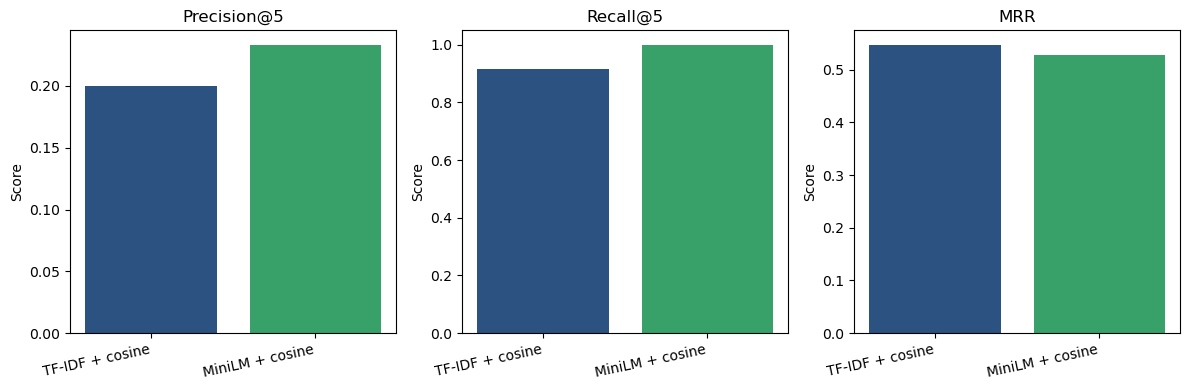

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
models = comparison["Model"].tolist()
x = np.arange(len(models))
for ax, col, title in zip(axes, ["precision@5", "recall@5", "mrr"], ["Precision@5", "Recall@5", "MRR"]):
    ax.bar(x, comparison[col], color=["#2c5282", "#38a169"][: len(models)])
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=12, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Score")
plt.tight_layout()
plt.show()


### Model comparison & tradeoffs

| Model | Precision@5 | Recall@5 | Notes |
|-------|---------------|-----------|-------|
| See `comparison` table above | numeric columns | numeric columns | TF-IDF: **speed** and token interpretability. MiniLM: **accuracy** on paraphrases, higher **latency** and model size. |

**Production:** This repo’s API (`semantic_search.py`) uses **MiniLM embeddings** over the full catalog, consistent with choosing semantic quality over the sparse baseline for student-facing search.
